# 📊 OS Atrasadas por Mês
Análise de ordens de serviço atrasadas com identificação de meses com feriados nacionais/prolongados.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import NullLocator
import warnings
warnings.filterwarnings("ignore")

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


## 1. Leitura dos dados

In [6]:
df_feriados = pd.read_csv("../trusted/trusted_feriados.csv")
df_os       = pd.read_csv("../refined/grafana/os_data_com_servicos.csv")

print(f"Feriados : {df_feriados.shape[0]:,} linhas | colunas: {df_feriados.columns.tolist()}")
print(f"Serviços : {df_os.shape[0]:,} linhas | colunas: {df_os.columns.tolist()}")

Feriados : 8,630 linhas | colunas: ['DATA', 'DIA', 'TIPO', 'DESCRICAO', 'ESTADO', 'CODIGO_MUNICIPIO']
Serviços : 73 linhas | colunas: ['id_ordem_servico', 'valor_total', 'valor_total_servicos', 'valor_total_produtos', 'data_saida_prevista', 'data_saida_efetiva', 'data_atualizacao', 'status', 'seguradora', 'nf_realizada', 'pagt_realizado', 'ativo', 'data_entrada_prevista', 'data_entrada_efetiva', 'id_registro_servico', 'fk_ordem_servico', 'preco_cobrado', 'parte_veiculo', 'lado_veiculo', 'tipo_servico', 'cor', 'especificacao_servico', 'tipo_pintura']


## 2. Exploração rápida

In [7]:
print("=== SERVIÇOS — primeiras linhas ===")
display(df_os[["id_ordem_servico","data_saida_prevista","data_saida_efetiva","status"]].head(8))

print("\nStatus únicos:")
print(df_os["status"].value_counts())

=== SERVIÇOS — primeiras linhas ===


,id_ordem_servico,data_saida_prevista,data_saida_efetiva,status
0,43,2021-01-12,2021-01-12,FINALIZADO
1,43,2021-01-12,2021-01-12,FINALIZADO
2,44,2021-01-16,2021-01-16,FINALIZADO
3,44,2021-01-16,2021-01-16,FINALIZADO
4,45,2021-01-19,2021-01-19,FINALIZADO
5,45,2021-01-19,2021-01-19,FINALIZADO
6,48,2021-03-08,2021-03-07,FINALIZADO
7,48,2021-03-08,2021-03-07,FINALIZADO



Status únicos:
status
FINALIZADO    73
Name: count, dtype: int64


## 3. Pré-processamento — Ordens de Serviço

In [8]:
# ── Converter datas
df_os["data_saida_prevista"] = pd.to_datetime(df_os["data_saida_prevista"], errors="coerce")
df_os["data_saida_efetiva"]  = pd.to_datetime(df_os["data_saida_efetiva"],  errors="coerce")

# ── Extrair mês e ano do prazo
df_os["mes"] = df_os["data_saida_prevista"].dt.month
df_os["ano"] = df_os["data_saida_prevista"].dt.year

# ── Desduplicar por OS (1 linha por ordem)
df_unique = df_os.drop_duplicates("id_ordem_servico").copy()

# ── Identificar OS atrasada:
#    • Finalizada após o prazo  OU
#    • Ainda aberta (não CANCELADO) com prazo já vencido
hoje = pd.Timestamp.today().normalize()
STATUS_IGNORAR = ["CANCELADO"]

df_unique["atrasada"] = (
    (df_unique["data_saida_efetiva"] > df_unique["data_saida_prevista"])
    | (
        df_unique["data_saida_efetiva"].isna()
        & (df_unique["data_saida_prevista"] < hoje)
        & ~df_unique["status"].isin(STATUS_IGNORAR)
    )
)

print(f"Total de OS únicas : {len(df_unique)}")
print(f"OS atrasadas       : {df_unique['atrasada'].sum()}")
display(df_unique[["id_ordem_servico","mes","data_saida_prevista","data_saida_efetiva","status","atrasada"]].head(10))

Total de OS únicas : 37
OS atrasadas       : 10


,id_ordem_servico,mes,data_saida_prevista,data_saida_efetiva,status,atrasada
0,43,1,2021-01-12,2021-01-12,FINALIZADO,False
2,44,1,2021-01-16,2021-01-16,FINALIZADO,False
4,45,1,2021-01-19,2021-01-19,FINALIZADO,False
6,48,3,2021-03-08,2021-03-07,FINALIZADO,False
8,49,3,2021-03-11,2021-03-11,FINALIZADO,False
10,50,3,2021-03-15,2021-03-15,FINALIZADO,False
13,53,3,2021-03-29,2021-03-29,FINALIZADO,False
15,54,5,2021-05-06,2021-05-05,FINALIZADO,False
17,55,5,2021-05-09,2021-05-09,FINALIZADO,False
19,57,5,2021-05-17,2021-05-17,FINALIZADO,False


## 4. Meses com feriado nacional ou prolongado

In [9]:
df_feriados["DATA"] = pd.to_datetime(df_feriados["DATA"], dayfirst=True, errors="coerce")

# Feriados NACIONAIS (sem estado específico ou TIPO == NACIONAL)
feriados_nacionais = df_feriados[
    df_feriados["TIPO"].str.upper().str.contains("NACIONAL", na=False)
].copy()

# Meses com ao menos 1 feriado nacional (qualquer ano disponível)
# Se quiser filtrar por ano específico, descomente e ajuste:
# ANO_FERIADO = 2026
# feriados_nacionais = feriados_nacionais[feriados_nacionais["DATA"].dt.year == ANO_FERIADO]

meses_com_feriado = set(feriados_nacionais["DATA"].dt.month.dropna().astype(int))

print(f"Tipos de feriado disponíveis: {df_feriados['TIPO'].unique()}")
print(f"Meses com feriado nacional  : {sorted(meses_com_feriado)}")

Tipos de feriado disponíveis: <StringArray>
['ESTADUAL', 'FACULTATIVO', 'NACIONAL', 'MUNICIPAL']
Length: 4, dtype: str
Meses com feriado nacional  : [1, 4, 5, 9, 10, 11, 12]


## 5. Cálculo do % de OS atrasadas por mês

In [10]:
MESES_NOMES = {
    1:"Jan", 2:"Fev", 3:"Mar", 4:"Abr", 5:"Mai", 6:"Jun",
    7:"Jul", 8:"Ago", 9:"Set", 10:"Out", 11:"Nov", 12:"Dez"
}

resumo = (
    df_unique.groupby("mes")["atrasada"]
    .agg(total="count", atrasadas="sum")
    .assign(pct=lambda x: (x["atrasadas"] / x["total"] * 100).round(0).astype(int))
    .reset_index()
)

resumo["nome"]        = resumo["mes"].map(MESES_NOMES)
resumo["tem_feriado"] = resumo["mes"].isin(meses_com_feriado)
resumo = resumo.sort_values("mes", ascending=False)

display(resumo[["nome","total","atrasadas","pct","tem_feriado"]])

,nome,total,atrasadas,pct,tem_feriado
9,Dez,3,0,0,True
8,Nov,10,6,60,True
7,Out,1,1,100,True
6,Set,4,0,0,True
5,Jul,5,0,0,False
4,Jun,1,1,100,False
3,Mai,4,0,0,True
2,Abr,1,1,100,True
1,Mar,4,0,0,False
0,Jan,4,1,25,True


## 6. Definição de cores por faixa

In [11]:
COR_VERDE    = "#2ECC71"   # < 30% — dentro do esperado
COR_AMARELO  = "#F5C842"   # 30–44% — atenção / mês com feriado
COR_VERMELHO = "#FF6B7A"   # ≥ 45% — crítico

def cor_barra(pct, tem_feriado):
    if pct >= 45:
        return COR_VERMELHO
    elif pct >= 30 or tem_feriado:
        return COR_AMARELO
    else:
        return COR_VERDE

resumo["cor"] = resumo.apply(lambda r: cor_barra(r["pct"], r["tem_feriado"]), axis=1)
print("Cores atribuídas:")
display(resumo[["nome","pct","tem_feriado","cor"]])

Cores atribuídas:


,nome,pct,tem_feriado,cor
9,Dez,0,True,#F5C842
8,Nov,60,True,#FF6B7A
7,Out,100,True,#FF6B7A
6,Set,0,True,#F5C842
5,Jul,0,False,#2ECC71
4,Jun,100,False,#FF6B7A
3,Mai,0,True,#F5C842
2,Abr,100,True,#FF6B7A
1,Mar,0,False,#2ECC71
0,Jan,25,True,#F5C842


## 7. Gráfico — OS Atrasadas por Mês

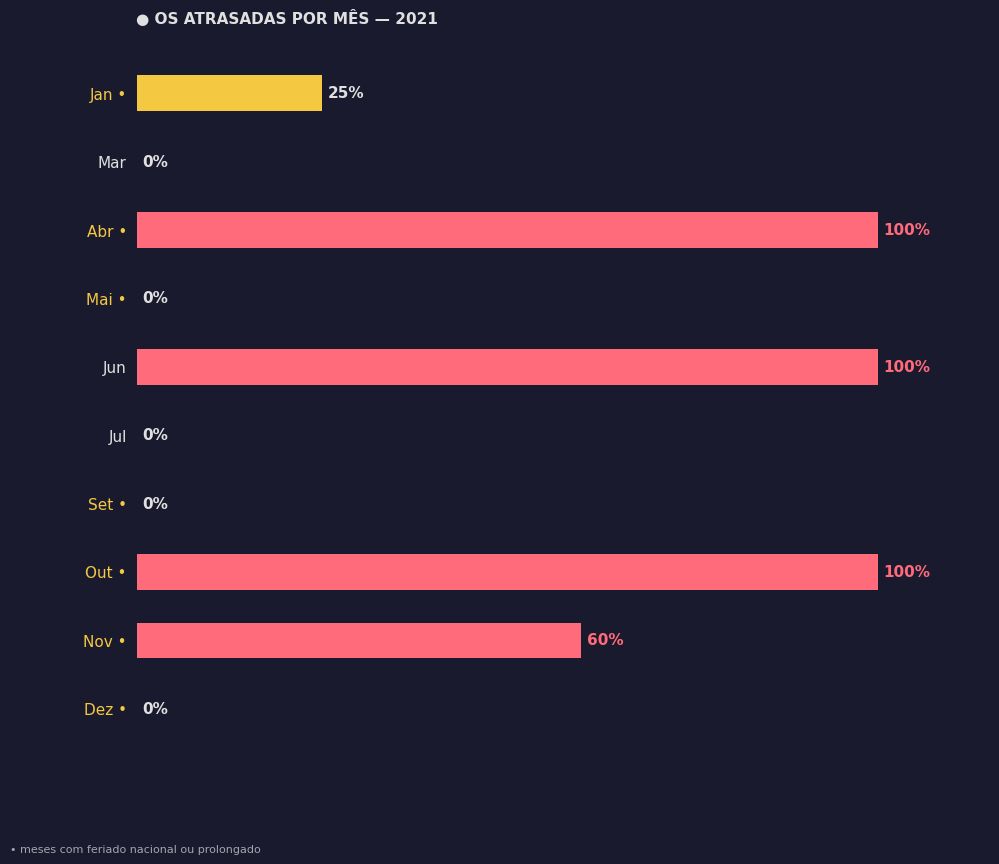

In [12]:
BG   = "#1A1A2E"
TEXT = "#E0E0E0"
ANO  = df_unique["ano"].mode()[0]  # ano predominante nos dados

fig, ax = plt.subplots(figsize=(11, 0.75 * len(resumo) + 1.8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    resumo["nome"],
    resumo["pct"],
    color=resumo["cor"],
    height=0.52,
    zorder=3
)

# ── Rótulos de percentual
for bar, (_, row) in zip(bars, resumo.iterrows()):
    cor_txt = row["cor"] if row["pct"] >= 30 else TEXT
    ax.text(
        row["pct"] + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{row['pct']}%",
        va="center", ha="left",
        color=cor_txt, fontsize=11, fontweight="bold"
    )

# ── Labels do eixo Y (• para meses com feriado)
ax.set_yticks(range(len(resumo)))
labels = [
    f"{r['nome']} •" if r["tem_feriado"] else r["nome"]
    for _, r in resumo.iterrows()
]
ax.set_yticklabels(labels, color=TEXT, fontsize=11)

for tick, (_, row) in zip(ax.get_yticklabels(), resumo.iterrows()):
    if row["tem_feriado"]:
        tick.set_color(COR_AMARELO)

# ── Título e rodapé
ax.set_title(
    f"● OS ATRASADAS POR MÊS — {ANO}",
    color=TEXT, fontsize=11, loc="left", pad=14, fontweight="bold"
)
fig.text(
    0.01, 0.01,
    "• meses com feriado nacional ou prolongado",
    color=TEXT, fontsize=8, alpha=0.7
)

# ── Estilo
ax.set_xlim(0, 115)
ax.xaxis.set_major_locator(NullLocator())
ax.tick_params(left=False, bottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)


In [14]:
# Salvar CSV pronto para o Grafana
resumo_grafana = resumo[["nome", "mes", "pct", "tem_feriado", "cor"]].copy()
resumo_grafana.columns = ["mes_nome", "mes_num", "pct_atrasadas", "tem_feriado", "cor"]
resumo_grafana = resumo_grafana.sort_values("mes_num")  # ordem cronológica
resumo_grafana.to_csv("../refined/grafana/os_atrasadas_grafana.csv", index=False)
print("✅ CSV exportado")

✅ CSV exportado
